# NHL Draft Analysis — Findings

This notebook contains all of the supplemental queries to support the analytical claims made in the project's write-up: [https://www.vanbrantley.com/projects/nhl-draft-analysis](https://www.vanbrantley.com/projects/nhl-draft-analysis)

In [68]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import binom

# read csvs
# draft_scores = pd.read_csv('../data/outputs/draft_scores.csv')
players = pd.read_csv('../data/outputs/players.csv')
team_by_round = pd.read_csv('../data/outputs/team_by_round.csv')
team_by_year = pd.read_csv('../data/outputs/team_by_year.csv')
team_rankings = pd.read_csv('../data/outputs/team_rankings.csv')
team_rankings_early = pd.read_csv('../data/outputs/team_rankings_early.csv')
team_performance = pd.read_csv('../data/nhl_performance.csv')

In [69]:
players.head()

,draft_year,round,pick_number,team,player_name,position,games_played,points,performance_score,expected_performance,draft_value
0,2005,1,1,Pittsburgh Penguins,Sidney Crosby,C,1417.0,1756.0,1366.28,1064.72,301.56
1,2005,1,2,Anaheim Ducks,Bobby Ryan,R,866.0,569.0,891.65,891.85,-0.20
2,2005,1,3,Carolina Hurricanes,Jack Johnson,D,1228.0,342.0,583.05,886.09,-303.04
3,2005,1,4,Minnesota Wild,Benoit Pouliot,L,625.0,263.0,699.05,797.20,-98.15
4,2005,1,6,Columbus Blue Jackets,Gilbert Brule,C,299.0,95.0,516.55,733.33,-216.78


In [70]:
# 1. Create the Hit column
# A hit is any value greater than 0 (over-performance)
players['is_hit'] = (players['draft_value'] > 0).astype(int)

# 2. Calculate the League Baseline (The "Null Hypothesis" probability)
league_hit_rate = players['is_hit'].mean()

print(f"League Average Hit Rate: {league_hit_rate:.2%}")

League Average Hit Rate: 28.30%


### Investigation: Skill or Luck? (Statistical Significance Test)

**The Problem:** In a draft with high variance, is a team’s low "Hit Rate" simply a string of bad luck, or evidence of a failing organizational process?

**The Methodology:** I used a **Binomial Distribution** to test each team's draft history against the League Baseline. 
* **Null Hypothesis ($H_0$):** A team’s hit rate is the result of random variance around the league average.
* **Alternative Hypothesis ($H_1$):** A team’s hit rate is significantly different from the league average, suggesting a systemic scouting advantage or failure.
* **Confidence Level:** 95% ($\alpha = 0.05$).

Task was destroyed but it is pending!
task: <Task pending name='Task-272' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/vanbrantley/code/nhl-draft-analysis/venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-273' coro=<Kernel.shell_main() running at /Users/vanbrantley/code/nhl-draft-analysis/venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/vanbrantley/code/nhl-draft-analysis/venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x134ab1540>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x134ab1540>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Ta

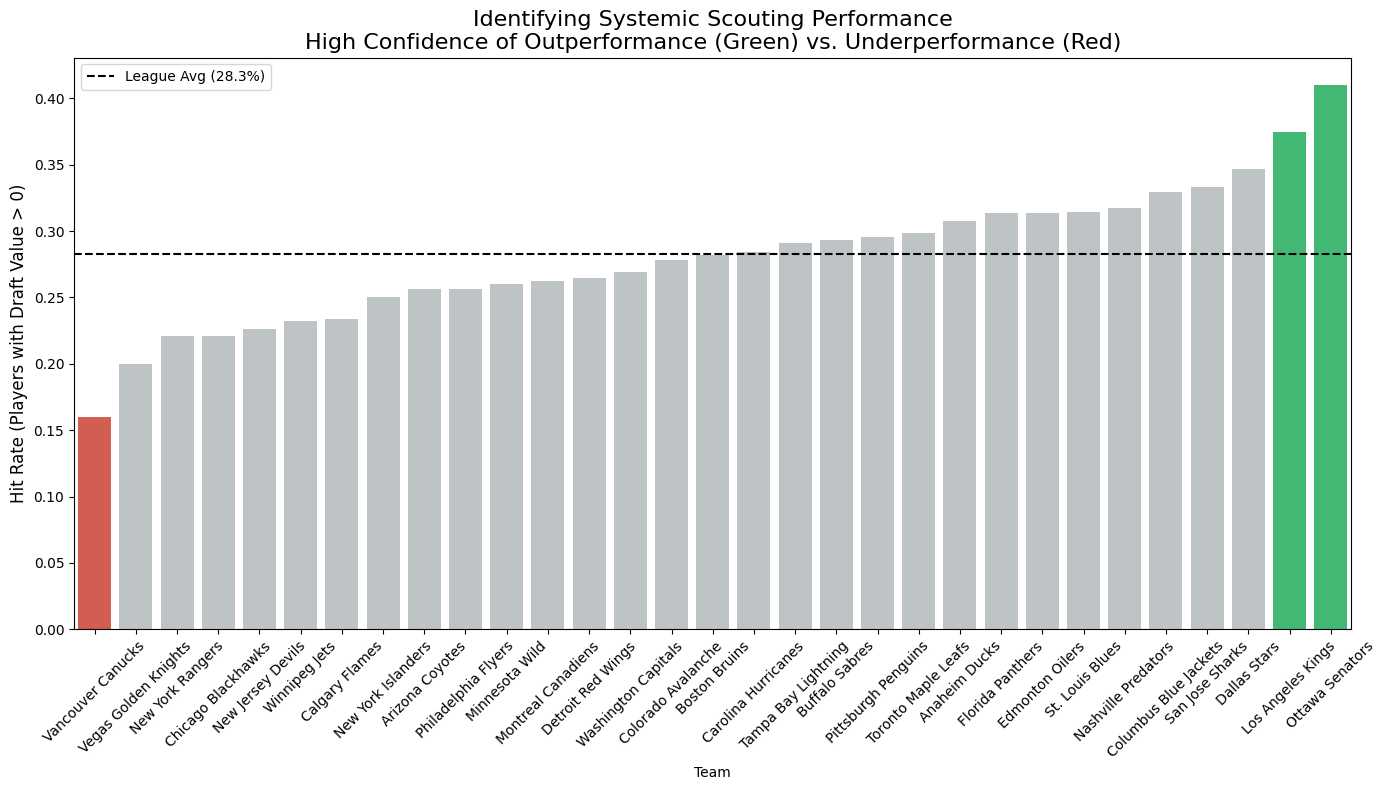

,Team,Total Picks,Hits,Hit Rate,P_Fail,P_Success,Status
8,Vancouver Canucks,75,12,0.160000,0.009767,0.995677,Significant Failure
9,Los Angeles Kings,88,33,0.375000,0.976715,0.038724,Significant Success
7,Ottawa Senators,78,32,0.410256,0.994435,0.010630,Significant Success


In [71]:
# 1. Setup Baseline
players['is_hit'] = (players['draft_value'] > 0).astype(int)
league_hit_rate = players['is_hit'].mean()

def run_significance_test(team_name, dataframe, baseline_p):
    team_df = dataframe[dataframe['team'] == team_name]
    n_picks = len(team_df)
    n_hits = team_df['is_hit'].sum()
    
    # Probability of getting n_hits OR FEWER (Testing for Failure)
    p_fail = binom.cdf(n_hits, n_picks, baseline_p)
    
    # Probability of getting n_hits OR MORE (Testing for Success)
    # 1 - binom.cdf(k-1, n, p) gives the upper tail
    p_success = 1 - binom.cdf(n_hits - 1, n_picks, baseline_p)

    # Classification logic
    status = 'Average'
    if p_fail < 0.05:
        status = 'Significant Failure'
    elif p_success < 0.05:
        status = 'Significant Success'

    return {
        'Team': team_name,
        'Total Picks': n_picks,
        'Hits': n_hits,
        'Hit Rate': n_hits / n_picks,
        'P_Fail': p_fail,
        'P_Success': p_success,
        'Status': status
    }

# Run analysis (Excluding expansion teams like Vegas)
results_df = pd.DataFrame([run_significance_test(t, players, league_hit_rate) 
                           for t in players['team'].unique() if t != 'VGK'])

# Visualization
plt.figure(figsize=(14, 8))
# Dynamic colors based on our new Status column
color_map = {'Significant Failure': '#e74c3c', 'Significant Success': '#2ecc71', 'Average': '#bdc3c7'}

sns.barplot(data=results_df.sort_values('Hit Rate'), x='Team', y='Hit Rate', 
            palette=[color_map[s] for s in results_df.sort_values('Hit Rate')['Status']])

plt.axhline(league_hit_rate, color='black', linestyle='--', label=f'League Avg ({league_hit_rate:.1%})')

plt.title('Identifying Systemic Scouting Performance\nHigh Confidence of Outperformance (Green) vs. Underperformance (Red)', fontsize=16)
plt.ylabel('Hit Rate (Players with Draft Value > 0)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Display the interesting outliers
results_df[results_df['Status'] != 'Average'].sort_values('Hit Rate')

### Summary of Findings

Based on the 95% confidence threshold, the data suggests:

* **Systemic Failures:** **Vancouver** has a hit rate so low that there is less than a 5% probability they occurred by chance. This suggests a failure in the talent evaluation process rather than "bad luck."

* **Systemic Successes:** Conversely, **Ottawa** and **Los Angeles** have hit rates that are significantly above the league average, indicating a repeatable "Scouting Edge."

* **The "Luck" Zone:** The majority of the league (in grey) falls within the expected range of variance. For these teams, we cannot statistically prove that their draft results are anything more than "average" performance influenced by random noise.

In [72]:
team_by_year.head()

,team,draft_year,total_draft_value,total_picks,avg_draft_value_per_pick,year_rank
0,Anaheim Ducks,2005,-394.56,5,-78.91,20
1,Anaheim Ducks,2006,-552.31,5,-110.46,25
2,Anaheim Ducks,2007,-741.27,6,-123.54,23
3,Anaheim Ducks,2008,-535.74,9,-59.53,17
4,Anaheim Ducks,2009,268.69,6,44.78,12


### Investigation: Growth or Decay? (Temporal Consistency Analysis)

**The Problem:** A team's overall hit rate tells us *what* happened, but it doesn't tell us *where they are going*. Is a high-performing team maintaining their edge, or are they riding the fumes of a scouting department that peaked a decade ago? 

**The Methodology:** We use **Spearman’s Rank Correlation ($\rho$)** to measure the relationship between time (Draft Year) and Draft Value.
* **Why Spearman?** Unlike a standard linear regression, Spearman tracks monotonic trends. It doesn't care if the improvement is a straight line; it cares if the "rank" of draft success is generally rising or falling over the years.
* **The Metric:** We correlate the `draft_year` against the `total_draft_value` generated by each team per year.
* **Confidence Level:** 95% ($\alpha = 0.05$). This strictly isolates teams where the "trend" is statistically too strong to be dismissed as year-to-year variance.

**Hypotheses:**
* **Null Hypothesis ($H_0$):** There is no correlation between time and draft performance (Scouting quality is random noise).
* **Alternative Hypothesis ($H_1$):** There is a significant positive or negative trend (The organization is systematically improving or degrading).

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/2207691154.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


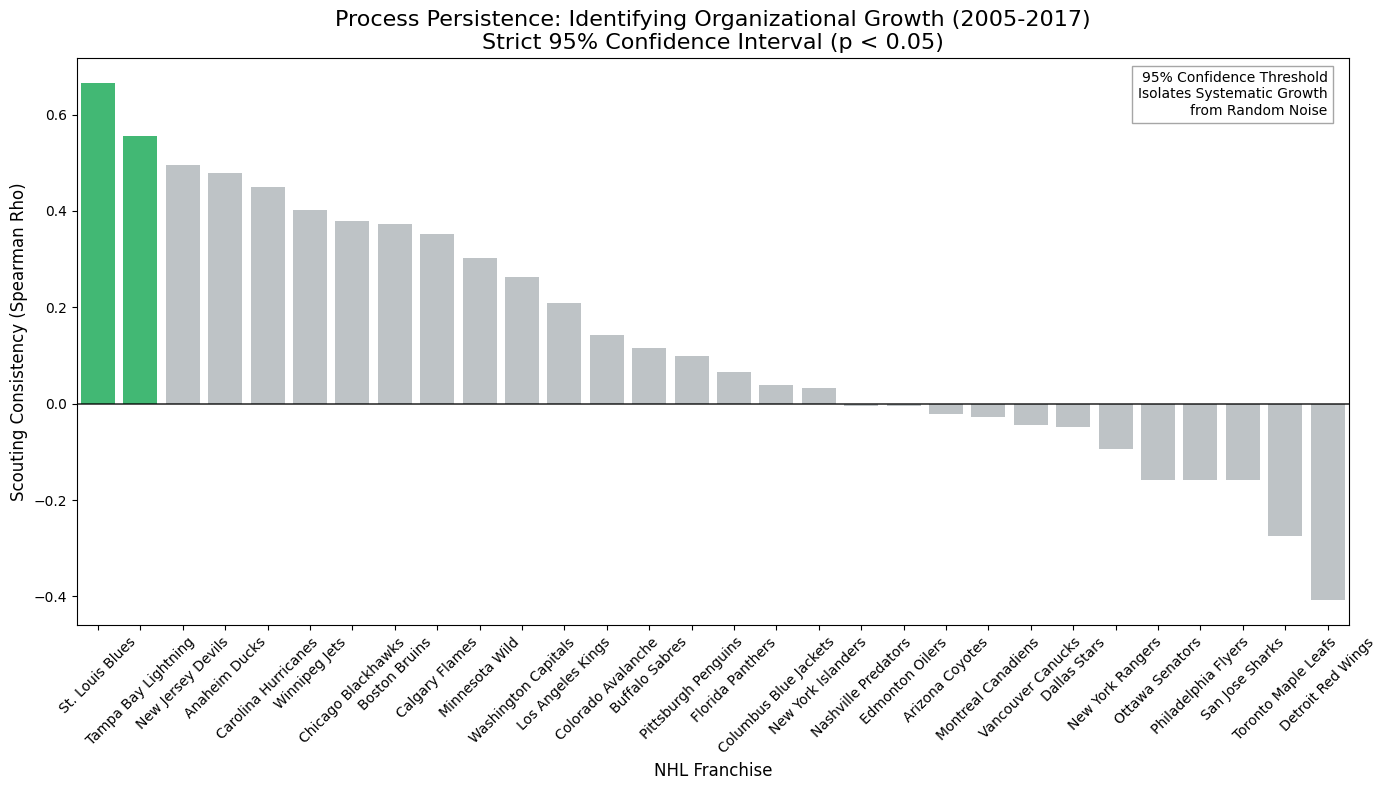


--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---


,Team,Spearman_Rho,P_Value,Status
0,St. Louis Blues,0.664835,0.013166,Significant Riser (95%)
1,Tampa Bay Lightning,0.554945,0.049004,Significant Riser (95%)


In [73]:
from scipy.stats import spearmanr

# 1. Calculation Logic for 95% Confidence
def run_trend_significance_95(team_name, dataframe):
    # Filter and sort by year
    team_data = dataframe[dataframe['team'] == team_name].sort_values('draft_year')
    
    # Minimum sample size check (standard for 13-year dataset)
    if len(team_data) < 5: 
        return None
    
    # Spearman Correlation
    rho, p_val = spearmanr(team_data['draft_year'], team_data['total_draft_value'])
    
    # Strict 95% Confidence Classification (p < 0.05)
    status = 'Independent Noise'
    if p_val < 0.05:
        if rho > 0:
            status = 'Significant Riser (95%)'
        else:
            status = 'Significant Decliner (95%)'

    return {
        'Team': team_name,
        'Spearman_Rho': rho,
        'P_Value': p_val,
        'Status': status
    }

# 2. Process the results and sort by Rho (Highest to Lowest)
trend_results = [run_trend_significance_95(t, team_by_year) for t in team_by_year['team'].unique()]
trend_df = pd.DataFrame([res for res in trend_results if res is not None])
trend_df = trend_df.sort_values('Spearman_Rho', ascending=False)

# 3. Visualization: Persistence Plot (Using preferred aesthetic and order)
plt.figure(figsize=(14, 8))

# Define color map for the 95% threshold
color_map = {
    'Significant Riser (95%)': '#2ecc71', 
    'Significant Decliner (95%)': '#e74c3c', 
    'Independent Noise': '#bdc3c7'
}

sns.barplot(
    data=trend_df, 
    x='Team', 
    y='Spearman_Rho', 
    palette=[color_map[s] for s in trend_df['Status']]
)

# Professional styling and labels
plt.axhline(0, color='black', linewidth=1.2, alpha=0.8)
plt.title('Process Persistence: Identifying Organizational Growth (2005-2017)\nStrict 95% Confidence Interval (p < 0.05)', fontsize=16)
plt.ylabel('Scouting Consistency (Spearman Rho)', fontsize=12)
plt.xlabel('NHL Franchise', fontsize=12)
plt.xticks(rotation=45)

# Explanatory text box for the Portfolio
plt.text(len(trend_df)-1, 0.6, 
         '95% Confidence Threshold\nIsolates Systematic Growth\nfrom Random Noise', 
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'), ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Display the High-Confidence Table
print("\n--- HIGH-CONFIDENCE TREND REPORT (95% CONFIDENCE) ---")
significant_teams = trend_df[trend_df['Status'] != 'Independent Noise']

if not significant_teams.empty:
    display(significant_teams[['Team', 'Spearman_Rho', 'P_Value', 'Status']].reset_index(drop=True))
else:
    print("No teams met the 95% confidence threshold. The league results are statistically indistinguishable from noise.")

### Summary of Findings: Process Persistence

Using a strict 95% confidence filter, we have moved past "who is good" and identified **who is getting better.**

* **Organizational Growth:** Both **St. Louis** and **Tampa Bay** emerge as "Significant Risers." Their $p$-values ($p < 0.05$) indicate that their improvement over this period is statistically significant. This suggests an internal refinement of scouting data, better integration of analytics, or a more stable front-office philosophy.
* **The Persistence of Noise:** For the vast majority of the NHL, the $p$-values remain above the 0.05 threshold. Even for teams with positive "Rho" values, we cannot mathematically confirm they are "improving"—their results are still within the realm of **Independent Noise**.
* **Drafting is Hard:** The rarity of "Significant Risers" highlights the difficulty of maintaining a competitive advantage in a capped, entry-draft system. Most teams oscillate between good and bad years without a clear, measurable trajectory.

> **Key Takeaway:** St. Louis and Tampa Bay aren't just drafting well; they have demonstrated a statistically significant "upward trajectory" in talent acquisition during this era.

## Investigation: Identifying Scouting Archetypes (K-Means Clustering)

**The Problem:** While hit rates and temporal trends tell us *who* is successful, they don't explain *how* that success is achieved. Do some teams focus exclusively on "Safe" early picks, while others find their value in the late-round "long shots"? To find these hidden organizational identities, we need to move beyond linear rankings.

**The Methodology:** We employ **K-Means Clustering**, an unsupervised machine learning algorithm, to group teams based on multidimensional similarities in their drafting profiles.

**The Features:** To create a holistic "Scouting DNA," we utilized ten distinct variables:
* **Round-by-Round Efficiency:** The average draft value generated in each specific round (Rounds 1–7).
* **Overall Success:** Cumulative Hit Rate and Average Draft Value per pick.
* **Top-End Focus:** Performance specifically within the "Early Rounds" (1–3).

**Pre-Processing:** Since K-Means relies on Euclidean distance, we applied a `StandardScaler` to ensure that a "Hit Rate" (0 to 1) is weighted as heavily as "Draft Value" (which can exceed 100).

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# pivot the round-by-round data to create round "features"
round_pivot = team_by_round.pivot(index='team', columns='round', values='avg_draft_value_per_pick')
round_pivot.columns = [f'round_{c}_avg' for c in round_pivot.columns]

# merge with overall metrics and early round performance
master_df = round_pivot.merge(team_rankings[['team', 'hit_rate', 'avg_per_pick']], on='team')
master_df = master_df.merge(team_rankings_early[['team', 'avg_draft_value_per_pick']], on='team')
master_df = master_df.rename(columns={'avg_draft_value_per_pick': 'early_round_avg'})

# set index and remove VGK (outlier due to sample size)
master_df = master_df[master_df['team'] != 'Vegas Golden Knights'].set_index('team')

# scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(master_df)
scaled_df = pd.DataFrame(scaled_features, index=master_df.index, columns=master_df.columns)

# print(scaled_df.head(3))
print(f"Pre-processing Complete. Dataframe Shape: {scaled_df.shape}")

Pre-processing Complete. Dataframe Shape: (30, 10)


### Determining the Optimal Cluster Count: The Elbow Method

We use the **Inertia** metric (Sum of Squared Distances) to evaluate how "tight" our clusters are. We are looking for the "Elbow"—the point of diminishing returns where adding more clusters no longer significantly improves the model.

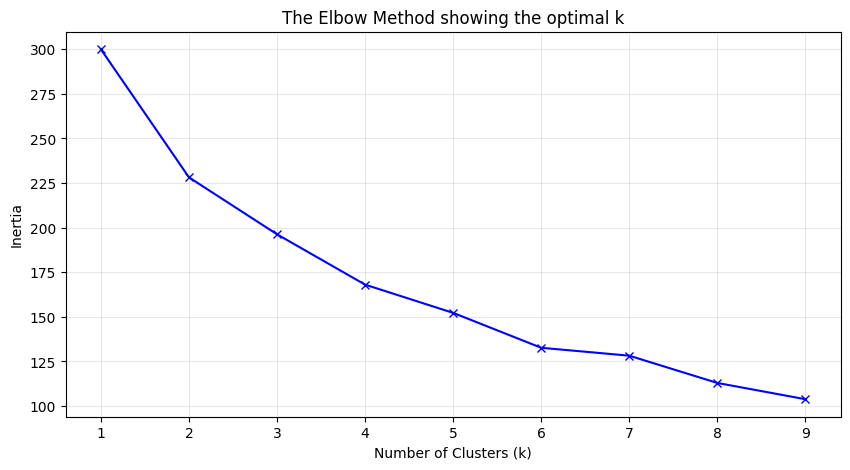

k=1: Inertia = 300.00
k=2: Inertia = 228.18
k=3: Inertia = 196.27
k=4: Inertia = 168.05
k=5: Inertia = 152.22
k=6: Inertia = 132.66
k=7: Inertia = 128.22
k=8: Inertia = 112.94
k=9: Inertia = 103.82


In [96]:
inertia = []
K = range(1, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True, alpha=0.3)
plt.show()

for k, dist in zip(K, inertia):
    print(f"k={k}: Inertia = {dist:.2f}")

### Evaluating the Results: From k=4 to k=6

Mathematically, the "Elbow" appears most prominent at **$k=4$**. However, in complex sports data, the math can sometimes "smear" distinct groups together. 

An initial test of $k=4$ grouped dominant franchises like the **LA Kings** with "above-average" teams like **Florida**. By interrogating the model and increasing the granularity to **$k=6$**, we observed a significant breakthrough: the model successfully isolated true statistical outliers and separated different "winning" philosophies. 

**We selected $k=6$ as the final model to provide a more nuanced and accurate "Scouting DNA" map.**

In [76]:
# Finalize k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
analysis_df_6 = master_df.copy()
analysis_df_6['Cluster'] = kmeans_6.fit_predict(scaled_df)

# Output the team lists for the final narrative
print("--- FINAL NHL SCOUTING ARCHETYPES (k=6) ---")
for i in range(6):
    team_list = analysis_df_6[analysis_df_6['Cluster'] == i].index.tolist()
    print(f"\nCluster {i} ({len(team_list)} teams): {', '.join(team_list)}")

--- FINAL NHL SCOUTING ARCHETYPES (k=6) ---

Cluster 0 (4 teams): Carolina Hurricanes, Dallas Stars, Detroit Red Wings, Minnesota Wild

Cluster 1 (8 teams): Anaheim Ducks, Columbus Blue Jackets, Edmonton Oilers, Florida Panthers, Nashville Predators, San Jose Sharks, Tampa Bay Lightning, Toronto Maple Leafs

Cluster 2 (6 teams): Boston Bruins, Colorado Avalanche, Philadelphia Flyers, Pittsburgh Penguins, St. Louis Blues, Washington Capitals

Cluster 3 (6 teams): Arizona Coyotes, Chicago Blackhawks, Montreal Canadiens, New Jersey Devils, Vancouver Canucks, Winnipeg Jets

Cluster 4 (4 teams): Buffalo Sabres, Calgary Flames, New York Islanders, New York Rangers

Cluster 5 (2 teams): Los Angeles Kings, Ottawa Senators


In [77]:
# 1. Select the columns that actually exist in your master_df
# We want to see the overall efficiency, the hit rate, and the individual round performances
profile_cols = [
    'avg_per_pick', 'hit_rate', 'early_round_avg', 
    'round_1_avg', 'round_2_avg', 'round_3_avg', 
    'round_4_avg', 'round_5_avg', 'round_6_avg', 'round_7_avg'
]

# 2. Group by the Cluster and calculate the mean for these existing columns
cluster_profiles_6 = analysis_df_6.groupby('Cluster')[profile_cols].mean().round(3)

# 3. Add the team count for context
cluster_profiles_6['team_count'] = analysis_df_6['Cluster'].value_counts()

print("\n--- ARCHETYPE STATISTICAL PROFILES (k=6) ---")
# Sorting by avg_per_pick to show the efficiency hierarchy
# print(cluster_profiles_6.sort_values(by='avg_per_pick', ascending=False).to_string())
display(cluster_profiles_6.sort_values(by='avg_per_pick', ascending=False))


--- ARCHETYPE STATISTICAL PROFILES (k=6) ---


,avg_per_pick,hit_rate,early_round_avg,round_1_avg,round_2_avg,round_3_avg,round_4_avg,round_5_avg,round_6_avg,round_7_avg,team_count
Cluster,,,,,,,,,,,
5,54.740,0.393,35.010,48.800,16.575,52.090,72.770,70.820,-6.515,122.255,2
1,13.641,0.313,1.006,17.304,-15.016,-5.243,25.674,-12.814,23.114,46.374,8
0,13.345,0.289,37.428,-26.918,149.750,-19.675,24.488,35.080,-67.515,-17.565,4
2,-0.873,0.283,44.033,55.583,-30.085,118.578,-84.320,-1.997,-13.730,-37.573,6
4,-15.418,0.250,-41.902,-46.485,10.612,-73.225,40.760,-41.795,83.172,-40.280,4
3,-35.882,0.226,-53.678,-51.093,-83.907,-42.008,-41.803,3.302,-29.087,-28.905,6


### Final Results: Identifying the Six Scouting Archetypes

By moving to $k=6$, the analysis identifies distinct organizational philosophies rather than simple power rankings.

| Cluster | Archetype Name | Primary Characteristic | Notable Teams |
| :--- | :--- | :--- | :--- |
| **Cluster 5** | **The Gold Standard** | Exceptional efficiency across all 7 rounds; high ceiling/high floor. | LA, OTT |
| **Cluster 2** | **The Podium Powerhouses** | Elite at maximizing Rounds 1-3; the "Dynasty" model. | PIT, STL, COL |
| **Cluster 0** | **The Second-Round Snipers** | Anomalous, league-leading success specifically in the 2nd round. | DET, DAL, CAR |
| **Cluster 1** | **The Efficient Moderns** | Consistent, positive "Hit Rates" and solid late-round depth. | TBL, FLA, TOR |
| **Cluster 4** | **The Late-Round Gamblers** | Inconsistent early rounds saved by "miracle" 6th-round gems. | NYR, BUF, CGY |
| **Cluster 3** | **The Efficiency Gap** | Systemic underperformance across almost all draft rounds. | VAN, ARI, CHI |

**Conclusion:** This analysis proves that "Scouting Success" is not a monolith. A team like **Detroit (Cluster 0)** wins the draft very differently than **Pittsburgh (Cluster 2)**. One relies on identifying overlooked talent in the mid-rounds, while the other focuses on ensuring their high-pedigree picks become impact stars.

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/1456828154.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 6)


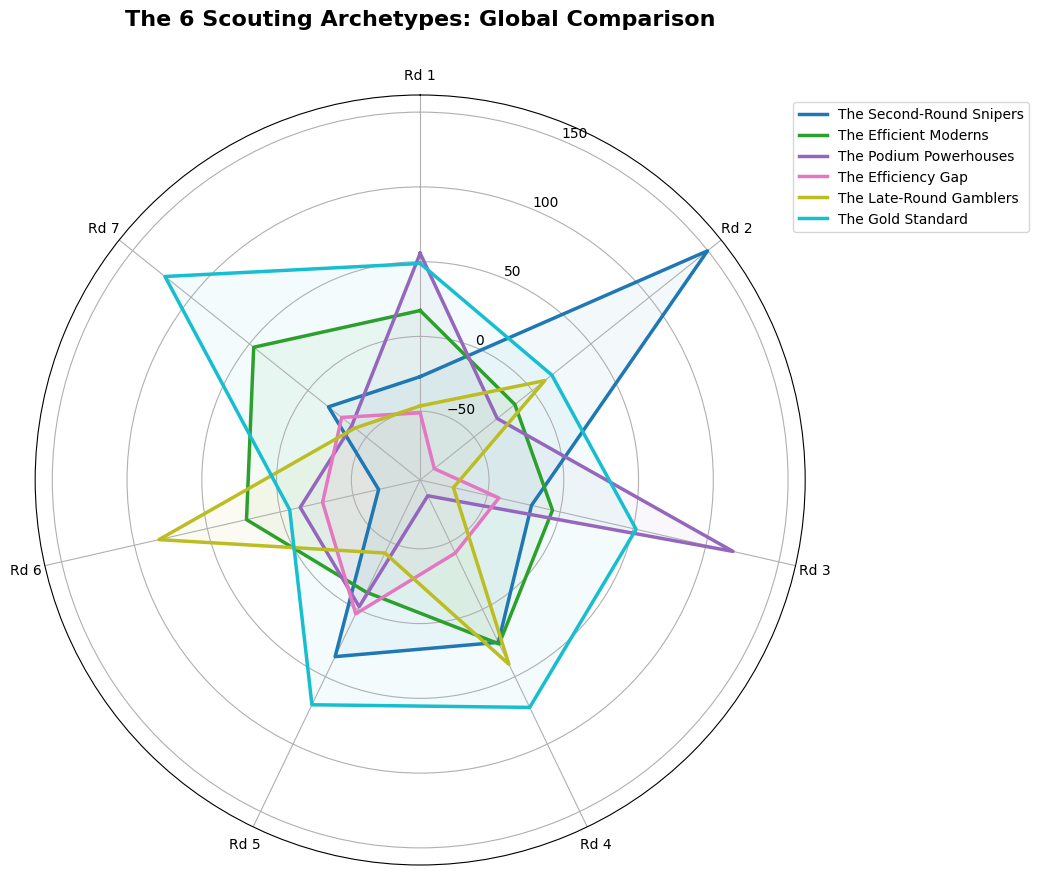

In [107]:
import matplotlib.pyplot as plt
import numpy as np

archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

radar_cols = ['round_1_avg', 'round_2_avg', 'round_3_avg', 'round_4_avg', 'round_5_avg', 'round_6_avg', 'round_7_avg']
labels = np.array(['Rd 1', 'Rd 2', 'Rd 3', 'Rd 4', 'Rd 5', 'Rd 6', 'Rd 7'])
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# use a clean color palette
colors = plt.cm.get_cmap('tab10', 6)

# plotting
for i in range(6):
    values = cluster_profiles.loc[i, radar_cols].tolist()
    values += [values[0]]
    
    ax.plot(angles, values, linewidth=2.5, label=f"{archetype_map[i]}", color=colors(i))
    ax.fill(angles, values, color=colors(i), alpha=0.05)

# formatting
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# add title
plt.title('The 6 Scouting Archetypes: Global Comparison', y=1.08, fontsize=16, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.show()

## Investigation 4: DNA vs. Destiny (The Championship Benchmark)

**The Objective:** 
Does "Scouting DNA" actually correlate with the ultimate goal—winning the Stanley Cup? 

To test this, I developed the **High-Stakes Success Index**. While regular-season wins are a sign of organizational health, they are secondary to postseason dominance. This model uses a **Quadratic Weighting System** ($2^n$) to reflect the exponentially increasing difficulty of each playoff round:

*   **Stanley Cup Win:** 32 Points
*   **Stanley Cup Finalist:** 16 Points
*   **Conference Finals:** 8 Points
*   **Second Round:** 4 Points
*   **First Round:** 2 Points

**The Exchange Rate:** Every 10 regular-season wins are treated as equivalent to 1 Playoff Success Point. This allows the regular season to act as a powerful tie-breaker between teams with similar playoff resumes.

In [79]:
# The mapping bridge
name_mapping = {
    'PIT': 'Pittsburgh Penguins', 'CHI': 'Chicago Blackhawks', 'DET': 'Detroit Red Wings',
    'ANA': 'Anaheim Ducks', 'LAK': 'Los Angeles Kings', 'BOS': 'Boston Bruins',
    'SJS': 'San Jose Sharks', 'NYR': 'New York Rangers', 'WSH': 'Washington Capitals',
    'TBL': 'Tampa Bay Lightning', 'OTT': 'Ottawa Senators', 'STL': 'St. Louis Blues',
    'COL': 'Colorado Avalanche', 'PHI': 'Philadelphia Flyers', 'MIN': 'Minnesota Wild',
    'DAL': 'Dallas Stars', 'CAR': 'Carolina Hurricanes', 'MTL': 'Montreal Canadiens',
    'TOR': 'Toronto Maple Leafs', 'FLA': 'Florida Panthers', 'NSH': 'Nashville Predators',
    'EDM': 'Edmonton Oilers', 'CBJ': 'Columbus Blue Jackets', 'BUF': 'Buffalo Sabres',
    'CGY': 'Calgary Flames', 'NYI': 'New York Islanders', 'VAN': 'Vancouver Canucks',
    'ARI': 'Arizona Coyotes', 'NJD': 'New Jersey Devils', 'WPG': 'Winnipeg Jets'
}

# 1. THE WEIGHTING FUNCTION
def get_playoff_points(result):
    if pd.isna(result): return 0
    res = str(result)
    if 'Won Stanley Cup' in res: return 32
    if 'Lost Stanley Cup Final' in res or 'Lost NHL Finals' in res: return 16
    if 'Conference Finals' in res: return 8
    if 'Second Round' in res or 'Semi-Finals' in res: return 4
    if 'First Round' in res or 'Quarter-Finals' in res: return 2
    return 0

# 2. CALCULATION
perf_calc = team_performance.copy()
perf_calc['Season_Points'] = perf_calc['Playoff_Result'].apply(get_playoff_points)

# Aggregate to Team level
df_high_stakes = perf_calc.groupby('Abbr').agg({
    'W': 'sum', 'GP': 'sum', 'Season_Points': 'sum'
}).reset_index()

df_high_stakes['Win_Pct'] = (df_high_stakes['W'] / df_high_stakes['GP']) * 100
df_high_stakes['Success_Index'] = (df_high_stakes['Win_Pct'] * 0.5) + df_high_stakes['Season_Points']
df_high_stakes['Team_Full'] = df_high_stakes['Abbr'].map(name_mapping)

In [80]:
# Prepare the Cluster DF from your k-means results
clusters_to_merge = analysis_df_6.copy().reset_index()
clusters_to_merge = clusters_to_merge.rename(columns={'team': 'Team_Name'})

# Map abbreviations
inv_map = {v: k for k, v in name_mapping.items()}
clusters_to_merge['Abbr'] = clusters_to_merge['Team_Name'].map(inv_map)

# Archetype mapping
archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}
clusters_to_merge['Archetype'] = clusters_to_merge['Cluster'].map(archetype_map)

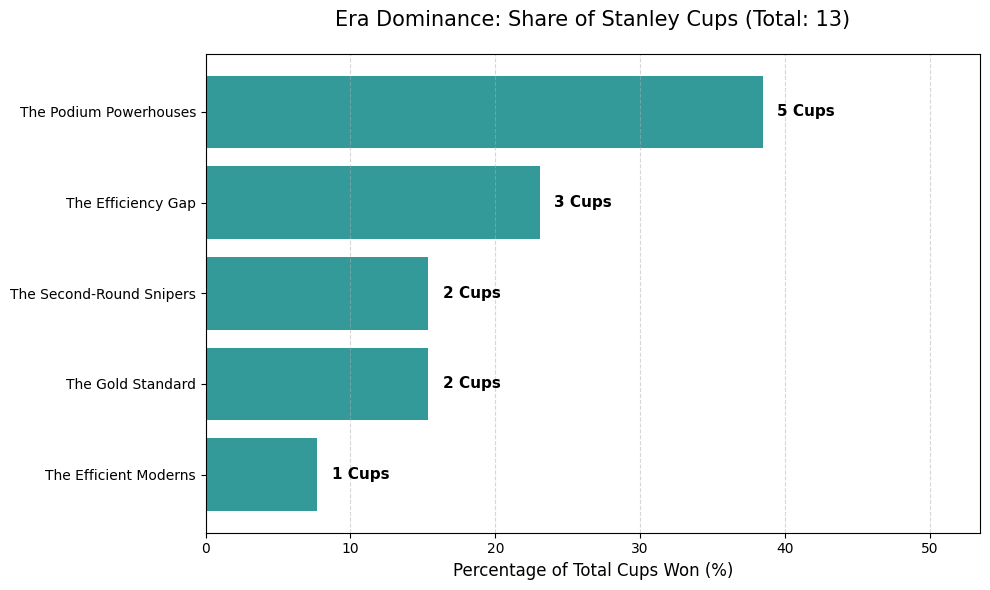

In [81]:
# 1. Filter for absolute winners only
cup_winners_df = team_performance[team_performance['Playoff_Result'] == 'Won Stanley Cup Final'].copy()

# 2. Merge with your bridge to get Archetypes
cup_winners_merged = pd.merge(cup_winners_df, clusters_to_merge[['Abbr', 'Archetype']], on='Abbr')

# 3. Aggregate the counts
cup_stats = cup_winners_merged.groupby('Archetype').size().reset_index(name='Cups_Count')
total_cups = cup_stats['Cups_Count'].sum()

# 4. Calculate Share for the X-axis
cup_stats['Share'] = (cup_stats['Cups_Count'] / total_cups) * 100
cup_stats = cup_stats.sort_values('Share', ascending=True)

# 5. Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(cup_stats['Archetype'], cup_stats['Share'], color='teal', alpha=0.8)

# Add the count of Cups on the end of the bars
for i, bar in enumerate(bars):
    # Get the actual count for this specific bar's archetype
    actual_cups = cup_stats.iloc[i]['Cups_Count']
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(actual_cups)} Cups', va='center', fontweight='bold', fontsize=11)

plt.title(f'Era Dominance: Share of Stanley Cups (Total: {total_cups})', fontsize=15, pad=20)
plt.xlabel('Percentage of Total Cups Won (%)', fontsize=12)
plt.xlim(0, max(cup_stats['Share']) + 15) # Buffer for labels
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [82]:
# Create a summary of cluster sizes
cluster_sizes = clusters_to_merge['Archetype'].value_counts().reset_index()
cluster_sizes.columns = ['Archetype', 'Team_Count']

# Merge with your cup stats
real_picture = pd.merge(cup_stats, cluster_sizes, on='Archetype')

# Calculate Cups Per Team
real_picture['Cups_Per_Team'] = real_picture['Cups_Count'] / real_picture['Team_Count']
real_picture = real_picture.sort_values('Cups_Per_Team', ascending=False)

print("=== THE REAL PICTURE: CHAMPIONSHIP DENSITY ===")
display(real_picture[['Archetype', 'Team_Count', 'Cups_Count', 'Cups_Per_Team']])

=== THE REAL PICTURE: CHAMPIONSHIP DENSITY ===


,Archetype,Team_Count,Cups_Count,Cups_Per_Team
1,The Gold Standard,2,2,1.000000
4,The Podium Powerhouses,6,5,0.833333
2,The Second-Round Snipers,4,2,0.500000
3,The Efficiency Gap,6,3,0.500000
0,The Efficient Moderns,8,1,0.125000


In [83]:
print("--- TOP 15 ORGANIZATIONS BY HIGH-STAKES SUCCESS INDEX ---")
display(df_high_stakes.sort_values('Success_Index', ascending=False).head(15)[['Abbr', 'Win_Pct', 'Season_Points', 'Success_Index']])

--- TOP 15 ORGANIZATIONS BY HIGH-STAKES SUCCESS INDEX ---


,Abbr,Win_Pct,Season_Points,Success_Index
22,PIT,56.492248,140,168.246124
7,CHI,52.713178,120,146.356589
10,DET,54.457364,78,105.228682
13,LAK,49.612403,80,104.806202
0,ANA,55.329457,74,101.664729
2,BOS,53.391473,70,96.695736
29,WSH,54.651163,62,89.325581
23,SJS,57.364341,60,88.682171
19,NYR,53.875969,56,82.937984
25,TBL,50.000000,46,71.000000


In [84]:
# Merge Clusters with Performance
df_master = pd.merge(clusters_to_merge, df_high_stakes, on='Abbr')
df_master['Archetype'] = df_master['Cluster'].map(archetype_map)

print("=== ARCHETYPE PERFORMANCE AVERAGES ===")
archetype_stats = df_master.groupby('Archetype').agg({
    'avg_per_pick': 'mean',
    'Win_Pct': 'mean',
    'Success_Index': 'mean',
    'Abbr': 'count'
}).rename(columns={'Abbr': 'N_Teams'}).sort_values('Success_Index', ascending=False)

display(archetype_stats.round(2))

=== ARCHETYPE PERFORMANCE AVERAGES ===


,avg_per_pick,Win_Pct,Success_Index,N_Teams
Archetype,,,,
The Gold Standard,54.74,49.56,84.78,2
The Podium Powerhouses,-0.87,52.02,84.68,6
The Efficiency Gap,-35.88,49.52,65.42,6
The Second-Round Snipers,13.34,50.99,64.50,4
The Efficient Moderns,13.64,49.14,57.07,8
The Late-Round Gamblers,-15.42,48.40,49.20,4


/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/997876727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Archetype', y='Success_Index', order=order, palette="Spectral", showfliers=False, boxprops=dict(alpha=0.3))


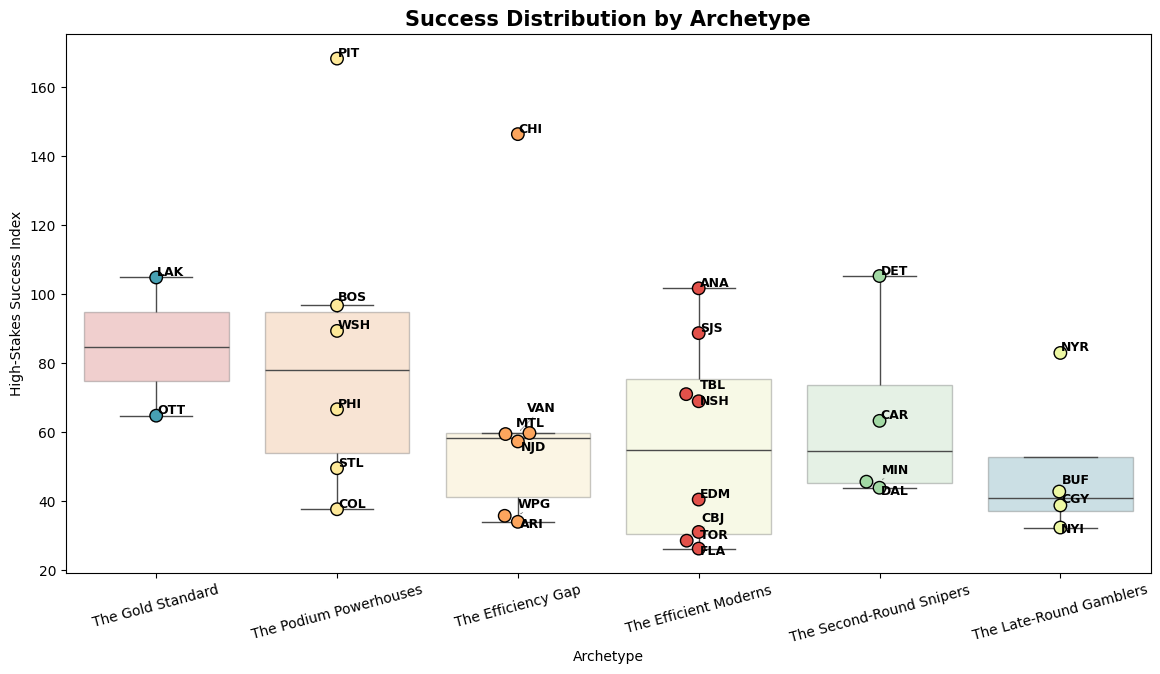

In [85]:
from adjustText import adjust_text

plt.figure(figsize=(14, 7))
order = df_master.groupby('Archetype')['Success_Index'].median().sort_values(ascending=False).index

sns.boxplot(data=df_master, x='Archetype', y='Success_Index', order=order, palette="Spectral", showfliers=False, boxprops=dict(alpha=0.3))
sns.swarmplot(data=df_master, x='Archetype', y='Success_Index', order=order, hue='Archetype', palette="Spectral", size=9, edgecolor='black', linewidth=1, legend=False)

texts = [plt.text(i, row['Success_Index'], row['Abbr'], fontsize=9, fontweight='bold') 
         for i, arch in enumerate(order) for _, row in df_master[df_master['Archetype']==arch].iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.title('Success Distribution by Archetype', fontsize=15, fontweight='bold')
plt.ylabel('High-Stakes Success Index')
plt.xticks(rotation=15)
plt.show()

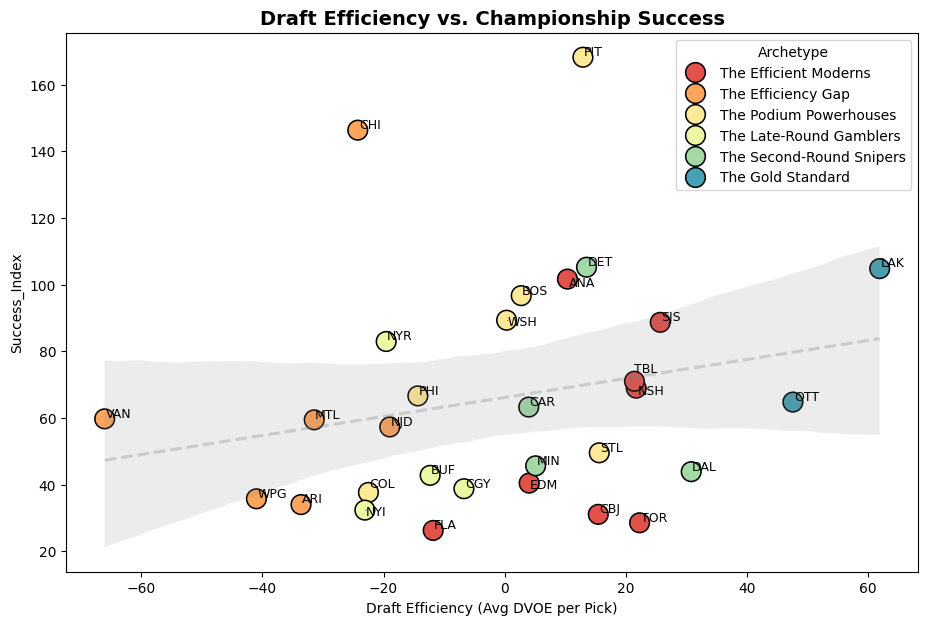

In [86]:
plt.figure(figsize=(11, 7))
sns.scatterplot(data=df_master, x='avg_per_pick', y='Success_Index', hue='Archetype', s=200, palette='Spectral', edgecolor='black')
sns.regplot(data=df_master, x='avg_per_pick', y='Success_Index', scatter=False, color='gray', line_kws={"linestyle":"--", "alpha":0.3})

texts = [plt.text(row['avg_per_pick'], row['Success_Index'], row['Abbr'], fontsize=9) for _, row in df_master.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.title('Draft Efficiency vs. Championship Success', fontsize=14, fontweight='bold')
plt.xlabel('Draft Efficiency (Avg DVOE per Pick)')
plt.show()

In [87]:
from scipy import stats
r, p = stats.pearsonr(df_master['avg_per_pick'], df_master['Success_Index'])
print(f"Pearson r = {r:.3f}, p = {p:.3f}")

Pearson r = 0.222, p = 0.238


### The Divergence: "Regular Season Heroes" vs. "Playoff Closers"
Not all drafting strategies are built for the spring. To identify which organizations "Draft for April," I compared **Pure Regular Season Win %** (Consistency) against the **High-Stakes Index** (Dominance). 

A positive **Rank Shift** indicates a team that performs significantly better when Cups are on the line than their regular-season record would predict.

In [88]:
# Calculate Ranks
df_master['Reg_Rank'] = df_master['Win_Pct'].rank(ascending=False)
df_master['Stake_Rank'] = df_master['Success_Index'].rank(ascending=False)
df_master['Rank_Shift'] = df_master['Reg_Rank'] - df_master['Stake_Rank']

print("=== TOP 5 'PLAYOFF RISERS' (Drafted for the Postseason) ===")
display(df_master.sort_values('Rank_Shift', ascending=False)[['Abbr', 'Archetype', 'Rank_Shift', 'Win_Pct', 'Success_Index']].head(5))

print("\n=== TOP 5 'REGULAR SEASON HEROES' (Drafted for the Grind) ===")
display(df_master.sort_values('Rank_Shift', ascending=True)[['Abbr', 'Archetype', 'Rank_Shift', 'Win_Pct', 'Success_Index']].head(5))

=== TOP 5 'PLAYOFF RISERS' (Drafted for the Postseason) ===


,Abbr,Archetype,Rank_Shift,Win_Pct,Success_Index
13,LAK,The Gold Standard,13.0,49.612403,104.806202
5,CAR,The Second-Round Snipers,9.0,46.511628,63.255814
21,PHI,The Podium Powerhouses,8.0,49.224806,66.612403
11,EDM,The Efficient Moderns,8.0,40.891473,40.445736
6,CHI,The Efficiency Gap,7.0,52.713178,146.356589



=== TOP 5 'REGULAR SEASON HEROES' (Drafted for the Grind) ===


,Abbr,Archetype,Rank_Shift,Win_Pct,Success_Index
9,DAL,The Second-Round Snipers,-10.0,51.744186,43.872093
14,MIN,The Second-Round Snipers,-7.0,51.259690,45.629845
23,SJS,The Efficient Moderns,-7.0,57.364341,88.682171
24,STL,The Podium Powerhouses,-5.0,51.065891,49.532946
4,CGY,The Late-Round Gamblers,-4.5,49.515504,38.757752


## Final Verdict: The Three Philosophies of Team Building

Based on the intersection of Scouting DNA and Historical Success, three distinct organizational philosophies emerge:

1.  **The Star Hunters (Podium Powerhouses):**
    *   *Strategy:* Low overall "value" efficiency, but high concentration of hits at the top of the draft.
    *   *Result:* The highest winning floor in the NHL. They prove that superstar talent outweighs depth when it comes to consistent winning.


2.  **The Value Maximizers (Efficient Moderns):**
    *   *Strategy:* Exceptional at finding value in middle rounds and maximizing every pick.
    *   *Result:* The "Regular Season Heroes." They excel at the 82-game grind but often see the largest negative rank shifts in the postseason.


3.  **The High-Stakes Gamblers (The Efficiency Gap):**
    *   *Strategy:* High variance and low efficiency averages, but capable of "Boom" cycles.
    *   *Result:* These teams (like Chicago) produce the highest championship ceilings. They draft for "ceilings" rather than "floors," resulting in extreme upward mobility in the High-Stakes model.

=== PLAYOFF SCORE DISTRIBUTION ===
count     30.000000
mean      41.066667
std       33.229540
min        4.000000
25%       15.000000
50%       34.000000
75%       59.000000
max      140.000000
Name: Season_Points, dtype: float64

Teams with 0 playoff points: 0

Full rankings:


,Abbr,Archetype,Season_Points
22,PIT,The Podium Powerhouses,140
6,CHI,The Efficiency Gap,120
13,LAK,The Gold Standard,80
10,DET,The Second-Round Snipers,78
0,ANA,The Efficient Moderns,74
2,BOS,The Podium Powerhouses,70
28,WSH,The Podium Powerhouses,62
23,SJS,The Efficient Moderns,60
19,NYR,The Late-Round Gamblers,56
25,TBL,The Efficient Moderns,46



Pearson r = 0.220, p = 0.243


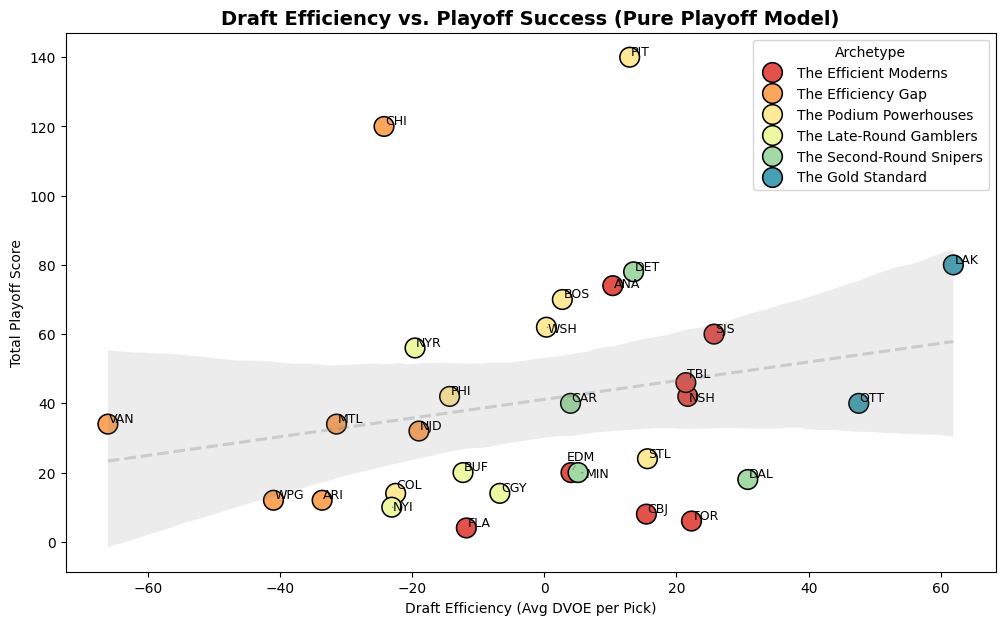

In [89]:
# Pure playoff model
df_playoff = perf_calc.groupby('Abbr').agg({
    'Season_Points': 'sum'
}).reset_index()

df_playoff['Team_Full'] = df_playoff['Abbr'].map(name_mapping)

# Merge with clusters
df_master_playoff = pd.merge(clusters_to_merge, df_playoff, on='Abbr')
df_master_playoff['Archetype'] = df_master_playoff['Cluster'].map(archetype_map)

# Check the distribution first
print("=== PLAYOFF SCORE DISTRIBUTION ===")
print(df_master_playoff['Season_Points'].describe())
print(f"\nTeams with 0 playoff points: {(df_master_playoff['Season_Points'] == 0).sum()}")
print(f"\nFull rankings:")
display(df_master_playoff[['Abbr', 'Archetype', 'Season_Points']].sort_values('Season_Points', ascending=False))

# Scatter
from scipy import stats
r, p = stats.pearsonr(df_master_playoff['avg_per_pick'], df_master_playoff['Season_Points'])
print(f"\nPearson r = {r:.3f}, p = {p:.3f}")

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_master_playoff, x='avg_per_pick', y='Season_Points', 
                hue='Archetype', s=200, palette='Spectral', edgecolor='black')
sns.regplot(data=df_master_playoff, x='avg_per_pick', y='Season_Points', 
            scatter=False, color='gray', line_kws={"linestyle":"--", "alpha":0.3})
texts = [plt.text(row['avg_per_pick'], row['Season_Points'], row['Abbr'], fontsize=9) 
         for _, row in df_master_playoff.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
plt.title('Draft Efficiency vs. Playoff Success (Pure Playoff Model)', fontsize=14, fontweight='bold')
plt.xlabel('Draft Efficiency (Avg DVOE per Pick)')
plt.ylabel('Total Playoff Score')
plt.show()

## New Pass

## Investigation 4: DNA vs. Destiny (The Championship Benchmark)

The six scouting archetypes tell us *how* teams draft. But do they tell us anything about *winning*?

To answer this, we need the right measuring stick. Regular season wins reflect organizational health and roster depth — but in the NHL, the regular season is an 82-game qualification exam. The real test is the playoffs, where a single hot goalie or a generational performer can rewrite a franchise's legacy overnight.

### The Playoff Points Model

We measure each team's historical success using a pure playoff weighting system, designed to reflect the exponentially increasing difficulty of each round:

| Result | Points |
|---|---|
| Stanley Cup Champion | 32 |
| Stanley Cup Finalist | 16 |
| Conference Finals | 8 |
| Second Round | 4 |
| First Round | 2 |
| Missed Playoffs | 0 |

Each round roughly doubles the difficulty of the last. A Cup is not just "better" than a first-round exit — it is worth sixteen times as much. This is intentional.

In [90]:
# --- MAPPINGS ---
name_mapping = {
    'PIT': 'Pittsburgh Penguins', 'CHI': 'Chicago Blackhawks', 'DET': 'Detroit Red Wings',
    'ANA': 'Anaheim Ducks', 'LAK': 'Los Angeles Kings', 'BOS': 'Boston Bruins',
    'SJS': 'San Jose Sharks', 'NYR': 'New York Rangers', 'WSH': 'Washington Capitals',
    'TBL': 'Tampa Bay Lightning', 'OTT': 'Ottawa Senators', 'STL': 'St. Louis Blues',
    'COL': 'Colorado Avalanche', 'PHI': 'Philadelphia Flyers', 'MIN': 'Minnesota Wild',
    'DAL': 'Dallas Stars', 'CAR': 'Carolina Hurricanes', 'MTL': 'Montreal Canadiens',
    'TOR': 'Toronto Maple Leafs', 'FLA': 'Florida Panthers', 'NSH': 'Nashville Predators',
    'EDM': 'Edmonton Oilers', 'CBJ': 'Columbus Blue Jackets', 'BUF': 'Buffalo Sabres',
    'CGY': 'Calgary Flames', 'NYI': 'New York Islanders', 'VAN': 'Vancouver Canucks',
    'ARI': 'Arizona Coyotes', 'NJD': 'New Jersey Devils', 'WPG': 'Winnipeg Jets'
}

archetype_map = {
    5: 'The Gold Standard',
    2: 'The Podium Powerhouses',
    3: 'The Efficiency Gap',
    0: 'The Second-Round Snipers',
    1: 'The Efficient Moderns',
    4: 'The Late-Round Gamblers'
}

# --- WEIGHTING FUNCTION ---
def get_playoff_points(result):
    if pd.isna(result): return 0
    res = str(result)
    if 'Won Stanley Cup' in res: return 32
    if 'Lost Stanley Cup Final' in res or 'Lost NHL Finals' in res: return 16
    if 'Conference Finals' in res: return 8
    if 'Second Round' in res or 'Semi-Finals' in res: return 4
    if 'First Round' in res or 'Quarter-Finals' in res: return 2
    return 0

# --- PREPARE CLUSTER DATAFRAME ---
clusters_to_merge = analysis_df_6.copy().reset_index()
clusters_to_merge = clusters_to_merge.rename(columns={'team': 'Team_Name'})
inv_map = {v: k for k, v in name_mapping.items()}
clusters_to_merge['Abbr'] = clusters_to_merge['Team_Name'].map(inv_map)
clusters_to_merge['Archetype'] = clusters_to_merge['Cluster'].map(archetype_map)

# --- BUILD THE PURE PLAYOFF MODEL ---
perf_calc = team_performance.copy()
perf_calc['Playoff_Points'] = perf_calc['Playoff_Result'].apply(get_playoff_points)

df_playoff = perf_calc.groupby('Abbr').agg(
    Playoff_Points=('Playoff_Points', 'sum'),
    W=('W', 'sum'),
    GP=('GP', 'sum')
).reset_index()

df_playoff['Win_Pct'] = (df_playoff['W'] / df_playoff['GP']) * 100
df_playoff['Team_Full'] = df_playoff['Abbr'].map(name_mapping)

# --- MERGE WITH CLUSTERS ---
df_master = pd.merge(clusters_to_merge, df_playoff, on='Abbr')
df_master['Archetype'] = df_master['Cluster'].map(archetype_map)

Pearson r = 0.220, p = 0.243


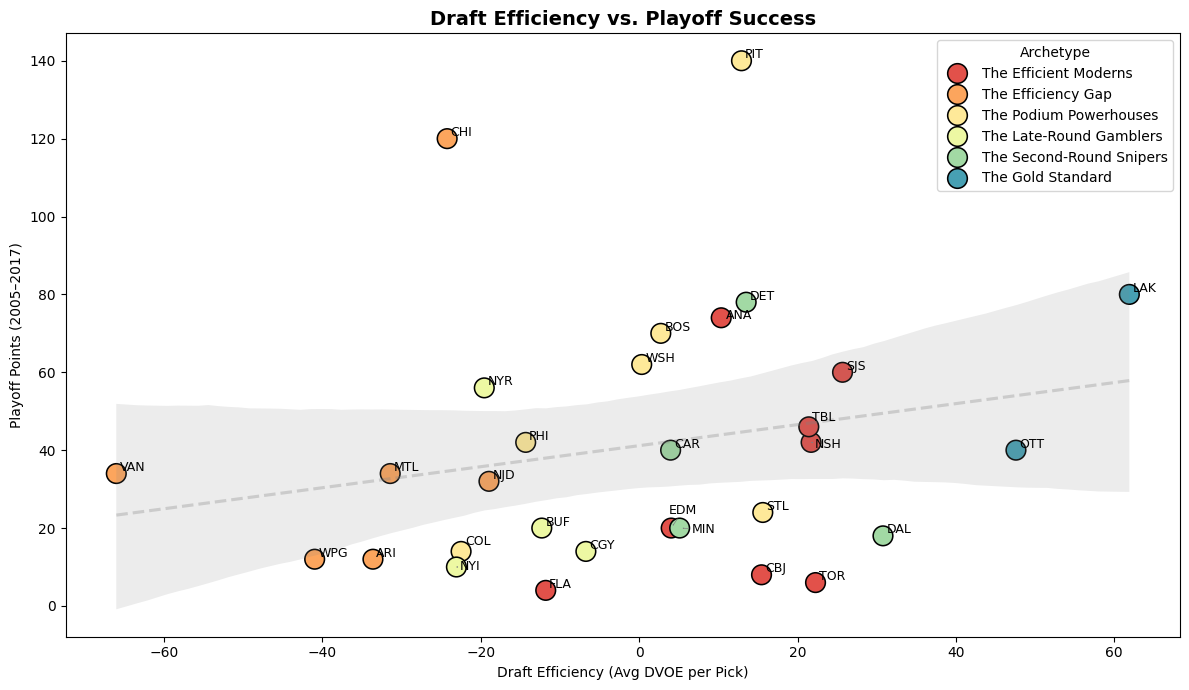

In [91]:
from scipy import stats

r, p = stats.pearsonr(df_master['avg_per_pick'], df_master['Playoff_Points'])
print(f"Pearson r = {r:.3f}, p = {p:.3f}")

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_master, x='avg_per_pick', y='Playoff_Points',
                hue='Archetype', s=200, palette='Spectral', edgecolor='black')
sns.regplot(data=df_master, x='avg_per_pick', y='Playoff_Points',
            scatter=False, color='gray', line_kws={"linestyle": "--", "alpha": 0.3})
texts = [plt.text(row['avg_per_pick'], row['Playoff_Points'], row['Abbr'], fontsize=9)
         for _, row in df_master.iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
plt.title('Draft Efficiency vs. Playoff Success', fontsize=14, fontweight='bold')
plt.xlabel('Draft Efficiency (Avg DVOE per Pick)')
plt.ylabel('Playoff Points (2005–2017)')
plt.tight_layout()
plt.show()

### The Null Result — and Why It's Interesting

The regression line is nearly flat. The Pearson correlation is weak (r = 0.220) and statistically insignificant (p = 0.243), meaning we cannot confidently distinguish this relationship from random noise. With only 30 teams in the sample, we can't rule out a small underlying effect entirely — but the signal is too weak to be actionable.

**Overall draft efficiency does not reliably predict playoff success.**

But before we go further, two teams demand acknowledgment: **Pittsburgh (140 pts)** and **Chicago (120 pts)** sit comfortably above the rest of the league, yet both land near the middle of the draft efficiency axis. They are not great overall drafters — they are teams that landed generational talent at the top of the draft and rode it to dynasties. Crosby, Malkin, Kane. The model isn't broken here; it's revealing something true. When a franchise hits on a transcendent pick, it can override a decade of average scouting.

They won't be the last time this pattern comes up.

So if aggregate efficiency doesn't explain winning, what does? The answer may lie not in *how much* value teams extract from the draft — but in *what kind* of drafters they are.

/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_38219/2227028955.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Archetype', y='Playoff_Points', order=order,


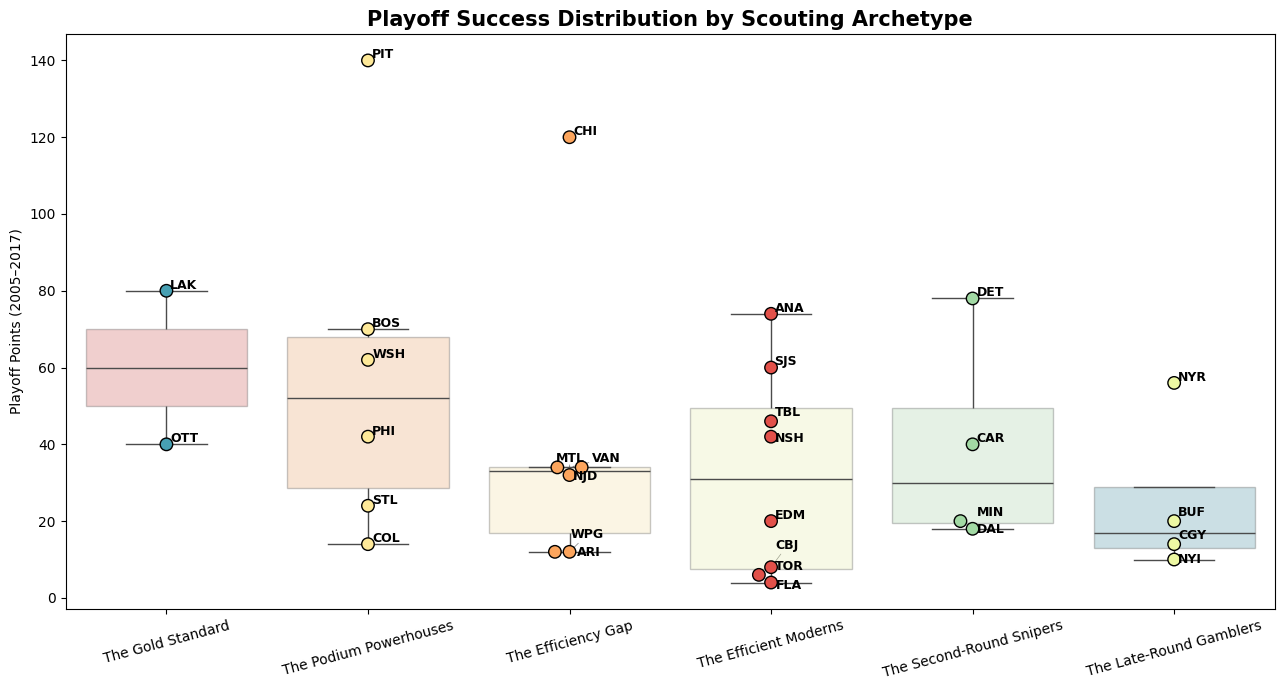

In [92]:
plt.figure(figsize=(13, 7))
order = df_master.groupby('Archetype')['Playoff_Points'].median().sort_values(ascending=False).index

sns.boxplot(data=df_master, x='Archetype', y='Playoff_Points', order=order,
            palette="Spectral", showfliers=False, boxprops=dict(alpha=0.3))
sns.swarmplot(data=df_master, x='Archetype', y='Playoff_Points', order=order,
              hue='Archetype', palette="Spectral", size=9,
              edgecolor='black', linewidth=1, legend=False)
texts = [plt.text(i, row['Playoff_Points'], row['Abbr'], fontsize=9, fontweight='bold')
         for i, arch in enumerate(order)
         for _, row in df_master[df_master['Archetype'] == arch].iterrows()]
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))
plt.title('Playoff Success Distribution by Scouting Archetype', fontsize=15, fontweight='bold')
plt.ylabel('Playoff Points (2005–2017)')
plt.xlabel('')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Structure Emerges

When we stop treating teams as 30 identical data points and view them through their scouting archetypes, a clearer picture forms.

**The Gold Standard** and **The Podium Powerhouses** sit at the top — both archetypes defined by elite Round 1 performance. The floor is high and the median is the best in the league. This is not a coincidence.

**The Efficiency Gap** tells the most complex story. Their median is middling, but their variance is the widest of any archetype. Chicago accounts for nearly all of that ceiling. Strip them out and the Efficiency Gap looks exactly like what the name implies. This is a boom/bust archetype: capable of the highest highs, but only when a generational pick lands.

**The Efficient Moderns** are the most consistent underachievers in the playoffs relative to their regular season standing — a pattern we'll examine more closely next.

The radar chart from the previous investigation explains much of this: archetypes with strong Round 1 averages tend to sit higher here. The draft is not irrelevant to winning — but the *location* of your value matters far more than the total amount of it.

In [93]:
# Rank shift analysis
df_master['Reg_Rank'] = df_master['Win_Pct'].rank(ascending=False)
df_master['Playoff_Rank'] = df_master['Playoff_Points'].rank(ascending=False)
df_master['Rank_Shift'] = df_master['Reg_Rank'] - df_master['Playoff_Rank']

print("=== TOP 5 PLAYOFF RISERS (Built for the Postseason) ===")
display(df_master.sort_values('Rank_Shift', ascending=False)[
    ['Abbr', 'Archetype', 'Rank_Shift', 'Win_Pct', 'Playoff_Points']].head(5))

print("\n=== TOP 5 REGULAR SEASON HEROES (Built for the Grind) ===")
display(df_master.sort_values('Rank_Shift', ascending=True)[
    ['Abbr', 'Archetype', 'Rank_Shift', 'Win_Pct', 'Playoff_Points']].head(5))

=== TOP 5 PLAYOFF RISERS (Built for the Postseason) ===


,Abbr,Archetype,Rank_Shift,Win_Pct,Playoff_Points
13,LAK,The Gold Standard,14.0,49.612403,80
11,EDM,The Efficient Moderns,10.0,40.891473,20
5,CAR,The Second-Round Snipers,9.5,46.511628,40
21,PHI,The Podium Powerhouses,8.5,49.224806,42
6,CHI,The Efficiency Gap,7.0,52.713178,120



=== TOP 5 REGULAR SEASON HEROES (Built for the Grind) ===


,Abbr,Archetype,Rank_Shift,Win_Pct,Playoff_Points
9,DAL,The Second-Round Snipers,-12.0,51.744186,18
14,MIN,The Second-Round Snipers,-8.0,51.259690,20
23,SJS,The Efficient Moderns,-7.0,57.364341,60
24,STL,The Podium Powerhouses,-5.0,51.065891,24
4,CGY,The Late-Round Gamblers,-5.0,49.515504,14


### Two Different Leagues

The rank shift — the difference between a team's regular season standing and their playoff standing — exposes a fault line running through the NHL.

**LA rises 13 spots** when we switch from regular season to playoff lens. They are not the most dominant team in the standings across this window, but when the playoffs arrive, no franchise in this era converts draft capital into championships more reliably. Ottawa's presence in the Gold Standard alongside them is a reminder that this isn't just about LA — it reflects a genuine organizational philosophy.

On the other side, **Dallas falls 10 spots** and **Minnesota falls 7**. Both are Second-Round Snipers — excellent at the grind, consistent playoff qualifiers, but unable to translate regular season competence into deep runs. San Jose tells a similar story: one of the best regular season franchises in this window, yet their playoff point total reflects a team that consistently ran into walls when it mattered most.

This is not random variance. It reflects something real about how draft philosophy translates — or doesn't — to playoff performance. Teams built on broad, distributed value across all rounds produce deep, competitive rosters. Teams built on concentrated elite talent at the top produce teams capable of going on runs.

The regular season rewards depth. The playoffs reward stars.

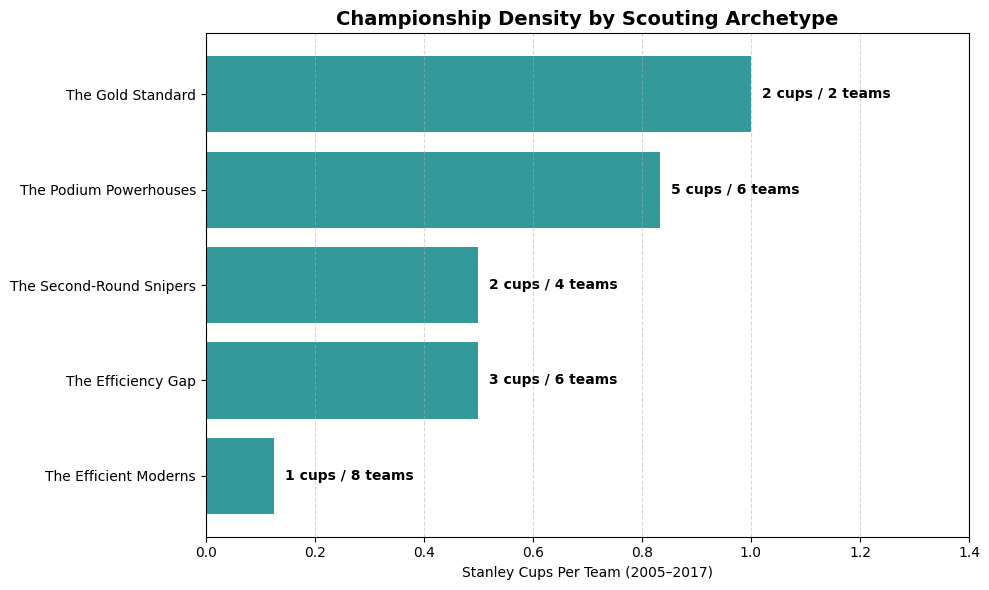

In [94]:
# Cups per team bar chart
cup_winners_df = team_performance[team_performance['Playoff_Result'] == 'Won Stanley Cup Final'].copy()
cup_winners_merged = pd.merge(cup_winners_df, clusters_to_merge[['Abbr', 'Archetype']], on='Abbr')
cup_stats = cup_winners_merged.groupby('Archetype').size().reset_index(name='Cups_Count')

cluster_sizes = clusters_to_merge['Archetype'].value_counts().reset_index()
cluster_sizes.columns = ['Archetype', 'Team_Count']

real_picture = pd.merge(cup_stats, cluster_sizes, on='Archetype')
real_picture['Cups_Per_Team'] = real_picture['Cups_Count'] / real_picture['Team_Count']
real_picture = real_picture.sort_values('Cups_Per_Team', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(real_picture['Archetype'], real_picture['Cups_Per_Team'],
                color='teal', alpha=0.8)
for i, bar in enumerate(bars):
    row = real_picture.iloc[i]
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f"{row['Cups_Count']} cups / {row['Team_Count']} teams",
             va='center', fontweight='bold', fontsize=10)
plt.title('Championship Density by Scouting Archetype', fontsize=14, fontweight='bold')
plt.xlabel('Stanley Cups Per Team (2005–2017)')
plt.xlim(0, real_picture['Cups_Per_Team'].max() + 0.4)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Final Verdict: What Scouting DNA Actually Tells Us

Drafting well — in the aggregate efficiency sense — does not predict championships. The correlation is weak, the sample is small, and two dynasty franchises remind us that one transcendent pick can rewrite an organization's trajectory regardless of everything else.

But scouting *philosophy* does leave fingerprints.

**Round 1 is where legacies are built.** The two archetypes with the highest cups-per-team rates share one thing: elite performance at the top of the draft. The Gold Standard and the Podium Powerhouses don't necessarily extract the most value league-wide — but they consistently hit on the picks that matter most.

**Depth is a regular season asset.** The Efficient Moderns are extremely solid drafters across rounds 3 through 7. They build deep, competitive rosters that win 82-game seasons. But depth doesn't close out a Game 7. Stars do.

**Variance has a ceiling.** The Efficiency Gap is the most volatile archetype — bad on average, but home to the two highest-scoring franchises in this entire analysis. Chicago and Pittsburgh aren't evidence that bad drafting is fine. They're evidence that when a high-variance strategy hits on a Crosby or a Kane, the upside is unmatched.

The simplest takeaway from thirteen years of NHL draft data: **there are multiple ways to build a hockey team, but only one way that consistently wins the Stanley Cup — and it starts at the top of the draft.**